# Statistics Project

In [1]:
# Importing the modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore
from sklearn.impute import SimpleImputer

#### Reading the dataset

In [2]:
# Reading the dataset
data=pd.read_csv('customer_behavior.csv')

## Preprocessing

#### Viewing the first 10 rows of the dataset

In [3]:
# Viewing the first 10 rows of the dataset
data.head(10)

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A
5,1006,Male,North,964.44,Fashion,Yes,A
6,1007,Male,West,1042.80,Electronics,No,A
7,1008,Female,West,860.81,Electronics,No,A
8,1009,Female,North,1386.42,Electronics,Yes,B
9,1010,Female,South,1391.58,Fashion,No,B


#### Displaying information about the dataset

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   str    
 2   Region           4825 non-null   str    
 3   PurchaseAmount   4850 non-null   float64
 4   ProductCategory  4474 non-null   str    
 5   Churn            4735 non-null   str    
 6   CampaignGroup    4815 non-null   str    
dtypes: float64(1), int64(1), str(5)
memory usage: 273.6 KB


#### Checking for null values

In [5]:
data.isna().sum()

CustomerID           0
Gender              97
Region             175
PurchaseAmount     150
ProductCategory    526
Churn              265
CampaignGroup      185
dtype: int64

***The columns Gender, Region, PurchaseAmount, ProductCategory, Churn and CampaignGroup contain null values.***

***Except PurchaseAmount column all other columns are categorical so filling the PurchaseAmount column with either the mean or median and filling the categorical columns with mode values of the respective columns.***

#### Creating a copy of the dataframe

In [6]:
data_copy=data.copy()
data_copy.head(10)

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A
5,1006,Male,North,964.44,Fashion,Yes,A
6,1007,Male,West,1042.80,Electronics,No,A
7,1008,Female,West,860.81,Electronics,No,A
8,1009,Female,North,1386.42,Electronics,Yes,B
9,1010,Female,South,1391.58,Fashion,No,B


#### Filling the null values in the columns

##### Filling the categorical columns with the mode values of the respective column

In [7]:
mode_imputer=SimpleImputer(strategy='most_frequent')
data_copy['Gender']=mode_imputer.fit_transform(data_copy[['Gender']]).ravel()
data_copy['Region']=mode_imputer.fit_transform(data_copy[['Region']]).ravel()
data_copy['ProductCategory']=mode_imputer.fit_transform(data_copy[['ProductCategory']]).ravel()
data_copy['Churn']=mode_imputer.fit_transform(data_copy[['Churn']]).ravel()
data_copy['CampaignGroup']=mode_imputer.fit_transform(data_copy[['CampaignGroup']]).ravel()

##### Checking if the PurchaseAmount column has outliers

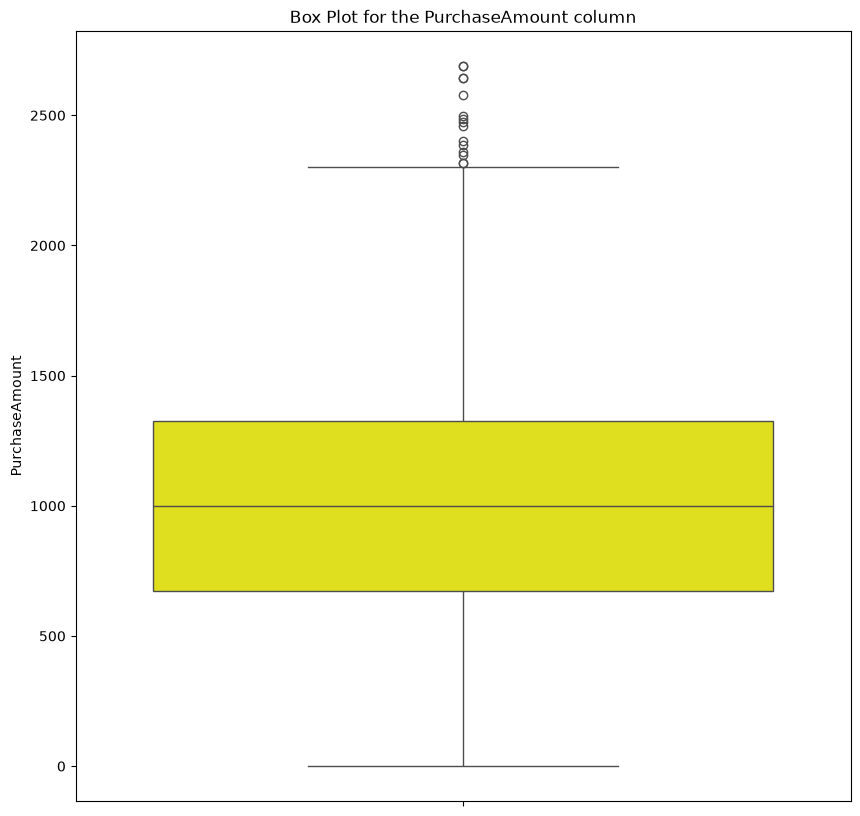

In [8]:
# Plotting a box plot for the PurchaseAmount column
fig, ax=plt.subplots(figsize=(10,10))
sns.boxplot(data=data_copy, y='PurchaseAmount',color='yellow')
ax.set_title("Box Plot for the PurchaseAmount column")
plt.show()

***Since the PurchaseAmount column has outliers, the null values in the column are filled with the median value of the column.***

#### Filling the PurchaseAmount column with the median value of the column

In [9]:
median_imputer=SimpleImputer(strategy='median')
data_copy['PurchaseAmount']=median_imputer.fit_transform(data_copy[['PurchaseAmount']])

#### Checking if there are any more null values

In [10]:
data_copy.isna().sum()

CustomerID         0
Gender             0
Region             0
PurchaseAmount     0
ProductCategory    0
Churn              0
CampaignGroup      0
dtype: int64

#### Checking for duplicate values

In [11]:
data_copy.duplicated().sum()

np.int64(0)

***There are no duplicate rows.***

## Average, Median and Mode of PurchaseAmount (Que1)

In [12]:
# Calculating the average
average=data_copy['PurchaseAmount'].mean()
print(f"Average of the PurchaseAmount column: {average}")

Average of the PurchaseAmount column: 1003.77455


In [13]:
# Calculating the median
median_value=data_copy['PurchaseAmount'].median()
print(f"Median value of the PurchaseAmount column: {median_value}")

Median value of the PurchaseAmount column: 998.0799999999999


In [14]:
# Calculating the mode 
mode_value=data_copy['PurchaseAmount'].mode()
print(f"Mode value of the PurchaseAmount column: {mode_value[0]}")

Mode value of the PurchaseAmount column: 998.0799999999999


## Outliers in PurchaseAmount Data (Que2)

### Using Box Plot

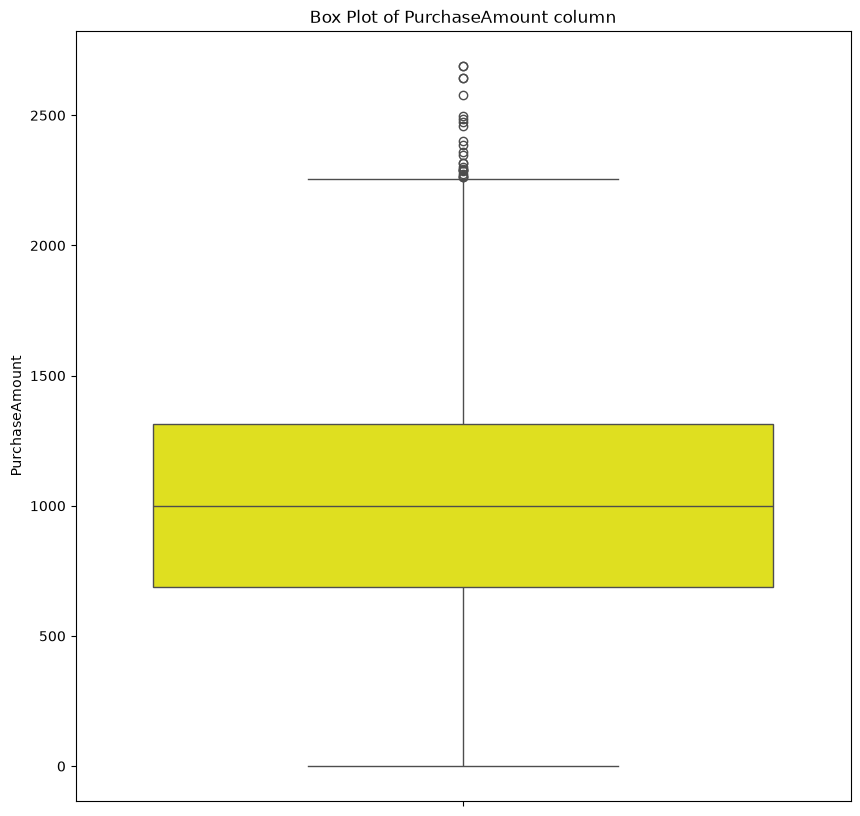

In [15]:
# Plotting box plot for the PurchaseAmount column
fig, ax=plt.subplots(figsize=(10,10))
sns.boxplot(data=data_copy, y='PurchaseAmount', color='yellow')
ax.set_title("Box Plot of PurchaseAmount column")
ax.set_ylabel("PurchaseAmount")
plt.show()

***From the box plot it can be seen that the PurchaseAmount column has outliers.***

### IQR method

In [16]:
# Calculating Q1, Q3 and IQR
Q1=data_copy['PurchaseAmount'].quantile(0.25)
Q3=data_copy['PurchaseAmount'].quantile(0.75)
IQR=Q3-Q1
print(f"IQR: {IQR}")

IQR: 629.76


In [17]:
# Calculating lower bound
lower_bound=Q1-(1.5*IQR)
print(f"Lower bound: {lower_bound}")

Lower bound: -258.245


In [18]:
# Calculating upper bound
upper_bound=Q3+(1.5*IQR)
print(f"Upper bound: {upper_bound}")

Upper bound: 2260.795


In [19]:
# Calculating the number of outlier values
outlier_count=data_copy[(data_copy['PurchaseAmount']<lower_bound) | (data_copy['PurchaseAmount']>upper_bound)]['PurchaseAmount'].count()
print(f"Number of outlier values: {outlier_count}")

Number of outlier values: 24


***Using the IQR method it has been identified that there are 24 outlier values.***

### Z-Score

In [20]:
# Calculating the Z-Score column
data_copy['z_score']=zscore(data_copy['PurchaseAmount'])
data_copy.head(10)

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup,z_score
0,1001,Male,South,256.07,Fashion,No,A,-1.574849
1,1002,Female,South,998.08,Electronics,Yes,B,-0.011994
2,1003,Female,West,1194.41,Fashion,No,A,0.401525
3,1004,Female,South,413.06,Grocery,No,A,-1.244190
4,1005,Male,West,1556.32,Fashion,Yes,A,1.163796
5,1006,Male,North,964.44,Fashion,Yes,A,-0.082848
6,1007,Male,West,1042.80,Electronics,No,A,0.082197
7,1008,Female,West,860.81,Electronics,No,A,-0.301118
8,1009,Female,North,1386.42,Electronics,Yes,B,0.805945
9,1010,Female,South,1391.58,Fashion,No,B,0.816813


In [21]:
outlier_count_zscore=data_copy[np.abs(data_copy['z_score'])>3]['PurchaseAmount'].count()
print(f"Number of outlier values: {outlier_count_zscore}")

Number of outlier values: 9


***Using the Z-Score method it has been identified that there are 9 outlier values.***

***Using Box plot, IQR method and Z-Score method, outlier values have been identified in the PurchaseAmount column.***

## Skewness and Kurtosis in the PurchaseAmount column (Que3)

## Skewness

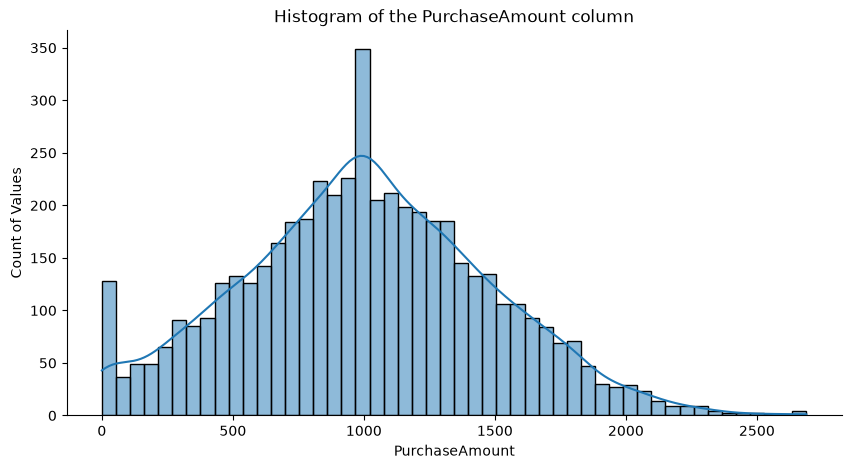

In [22]:
# Plotting histogram for the PurchaseAmount column
fig, ax=plt.subplots(figsize=(10,5))
sns.histplot(
    data=data_copy,
    x='PurchaseAmount',
    bins=50,
    kde=True
)
ax.set_title("Histogram of the PurchaseAmount column")
ax.set_xlabel('PurchaseAmount')
ax.set_ylabel('Count of Values')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [23]:
# Calculating the skew
skew_value=data_copy['PurchaseAmount'].skew()
print(f"Skew value of the PurchaseAmount column: {skew_value}")

Skew value of the PurchaseAmount column: 0.10883141246252831


***The skew value of the PurchaseAmount column is very low, therefore the column is almost symmetric.***

### Kurtosis

In [24]:
# Calculating the kurtosis
kurt_value=data_copy['PurchaseAmount'].kurt()
print(f"Kurtosis value of the PurchaseAmount column: {kurt_value}")

Kurtosis value of the PurchaseAmount column: -0.17665360565282562


***The kurtosis value of the PurchaseAmount column indicates that the data is slightly platykurtic.***

## Difference in spending between male and female customers (Que4)

1. Comparing means of two samples.
2. Large sample size.

#### Conducting Two Sample Z-Test

**Null Hypothesis:** There is no significant difference in spending between male and female customers.

**Alternate Hypothesis:** There is significant difference in spending between male and female customers.

In [25]:
from statsmodels.stats.weightstats import ztest

amount_spend_male=data_copy[data_copy['Gender']=='Male']['PurchaseAmount']
amount_spend_female=data_copy[data_copy['Gender']=='Female']['PurchaseAmount']
alpha=0.05
z_stat, p_value=ztest(amount_spend_male,amount_spend_female)
print("Result of Two Sample Z-test")
print(f"Z-Statistic: {z_stat}")
print(f"P value: {p_value}")


Result of Two Sample Z-test
Z-Statistic: 2.271977288589545
P value: 0.02308788211172719


In [26]:
if p_value<alpha:
    print("Reject Null Hypothesis")
else:
    print("Failed to reject Null Hypothesis")

Reject Null Hypothesis


***There is a significant difference in spending between male and female customers.***

## Relationship between ProductCategory and customer churn (Que5)

1. Identifying relatioship between two categorical variables.

#### Conducting Chi-Square Test

**Null Hypothesis:** There is no relationship between ProductCategory and customer churn.

**Alternate Hypothesis:** There is relationship between ProductCategory and customern churn.

In [27]:
from scipy.stats import chi2_contingency

contigency_table=pd.crosstab(data_copy['ProductCategory'], data_copy['Churn'])
alpha=0.05
chi2, p_value, dof, expected=chi2_contingency(contigency_table)
print("Result of Chi-Square Test")
print(f"Chi-square Statistic: {chi2}")
print(f"P value: {p_value}")
print(f"Degrees of Freedom: {dof}")

Result of Chi-Square Test
Chi-square Statistic: 0.9320029725740938
P value: 0.6275063513920858
Degrees of Freedom: 2


In [28]:
if p_value<alpha:
    print("Reject Null Hypothesis")
else:
    print("Failed to reject Null Hypothesis")

Failed to reject Null Hypothesis


***There is no relationship between ProductCategory and customer churn.***

## Purchase Amount vary significantly across different regions (Que6)

1. Comparing means across more than two groups.

#### Conducting One Way ANOVA Test

**Null Hypothesis:** Purchase amount doesnot vary significantly across different regions.

**Alternate Hypothesis:** Purchase amount vary significantly across different regions.

In [29]:
from scipy.stats import f_oneway

purchase_region=data_copy.groupby(by=['Region'])['PurchaseAmount']
purchase_region_array=[group for region, group in purchase_region]
alpha=0.05
F_stat, p_value=f_oneway(*purchase_region_array)
print("Result of One Way ANOVA Test")
print(f"F-statistic: {F_stat}")
print(f"P value: {p_value}")

Result of One Way ANOVA Test
F-statistic: 0.38656582634080366
P value: 0.7626903055040781


In [30]:
if p_value<alpha:
    print("Reject Null Hypothesis")
else:
    print("Failed to reject Null Hypothesis")

Failed to reject Null Hypothesis


***Purchase amount doesnot vary significantly across different regions.***

## Email Campaign (A or B) performed better in terms of average PurchaseAmount (Que7)

1. Comparing means of two samples.
2. Large sample size.

#### Conducting Two Sample Z-Test

**Null Hypothesis:** Performance of A = Performance of B

**Alternate Hypothesis:** Performance of A not equal to Performance of B

In [31]:
from statsmodels.stats.weightstats import ztest

amount_A=data_copy[data_copy['CampaignGroup']=='A']['PurchaseAmount']
amount_B=data_copy[data_copy['CampaignGroup']=='B']['PurchaseAmount']
alpha=0.05
z_stat, p_value=ztest(amount_A, amount_B)
print("Result of Two Sample Z-test")
print(f"Z-Statistic: {z_stat}")
print(f"P value: {p_value}")

Result of Two Sample Z-test
Z-Statistic: 1.3250518698083606
P value: 0.18515394805743723


In [32]:
if p_value<alpha:
    print("Reject Null Hypothesis")
else:
    print("Failed to reject Null Hypothesis")

Failed to reject Null Hypothesis


***Performance of email campaigns A and B are same.***

## PurchaseAmount follows a normal Distribution ? (Que8)

In [33]:
# Calculating the skew
skew_value=data_copy['PurchaseAmount'].skew()
print(f"Skew value of the PurchaseAmount column: {skew_value}")

Skew value of the PurchaseAmount column: 0.10883141246252831


In [34]:
# Calculating the kurtosis
kurt_value=data_copy['PurchaseAmount'].kurt()
print(f"Kurtosis value of the PurchaseAmount column: {kurt_value}")

Kurtosis value of the PurchaseAmount column: -0.17665360565282562


***Since the skewness value and kurtosis value of PurchaseAmount column is low(close to zero), we can assume that PurchaseAmount follows a normal distribution.***

## Insights by applying the Central Limit Theorem (Que9)

In [35]:
# Calculating the mean of 1000 samples of size 50
means_of_samples_500=[]
means_of_samples_1000=[]
means_of_samples_1500=[]
means_of_samples_2000=[]
means_of_samples_2500=[]
means_of_samples_3000=[]
means_of_samples_3500=[]
means_of_samples_4000=[]
means_of_samples_4500=[]
means_of_samples_5000=[]
for i in range(10000):
    if i<500:
        means_of_samples_500.append(data_copy['PurchaseAmount'].sample(n=50, replace=True).mean())
    if i<1000:
        means_of_samples_1000.append(data_copy['PurchaseAmount'].sample(n=50, replace=True).mean())
    if i<1500:
        means_of_samples_1500.append(data_copy['PurchaseAmount'].sample(n=50, replace=True).mean())
    if i<2000:
        means_of_samples_2000.append(data_copy['PurchaseAmount'].sample(n=50, replace=True).mean())
    if i<2500:
        means_of_samples_2500.append(data_copy['PurchaseAmount'].sample(n=50, replace=True).mean())
    if i<3000:
        means_of_samples_3000.append(data_copy['PurchaseAmount'].sample(n=50, replace=True).mean())
    if i<3500:
        means_of_samples_3500.append(data_copy['PurchaseAmount'].sample(n=50, replace=True).mean())
    if i<4000:
        means_of_samples_4000.append(data_copy['PurchaseAmount'].sample(n=50, replace=True).mean())
    if i<4500:
        means_of_samples_4500.append(data_copy['PurchaseAmount'].sample(n=50, replace=True).mean())
    means_of_samples_5000.append(data_copy['PurchaseAmount'].sample(n=50, replace=True).mean())
    

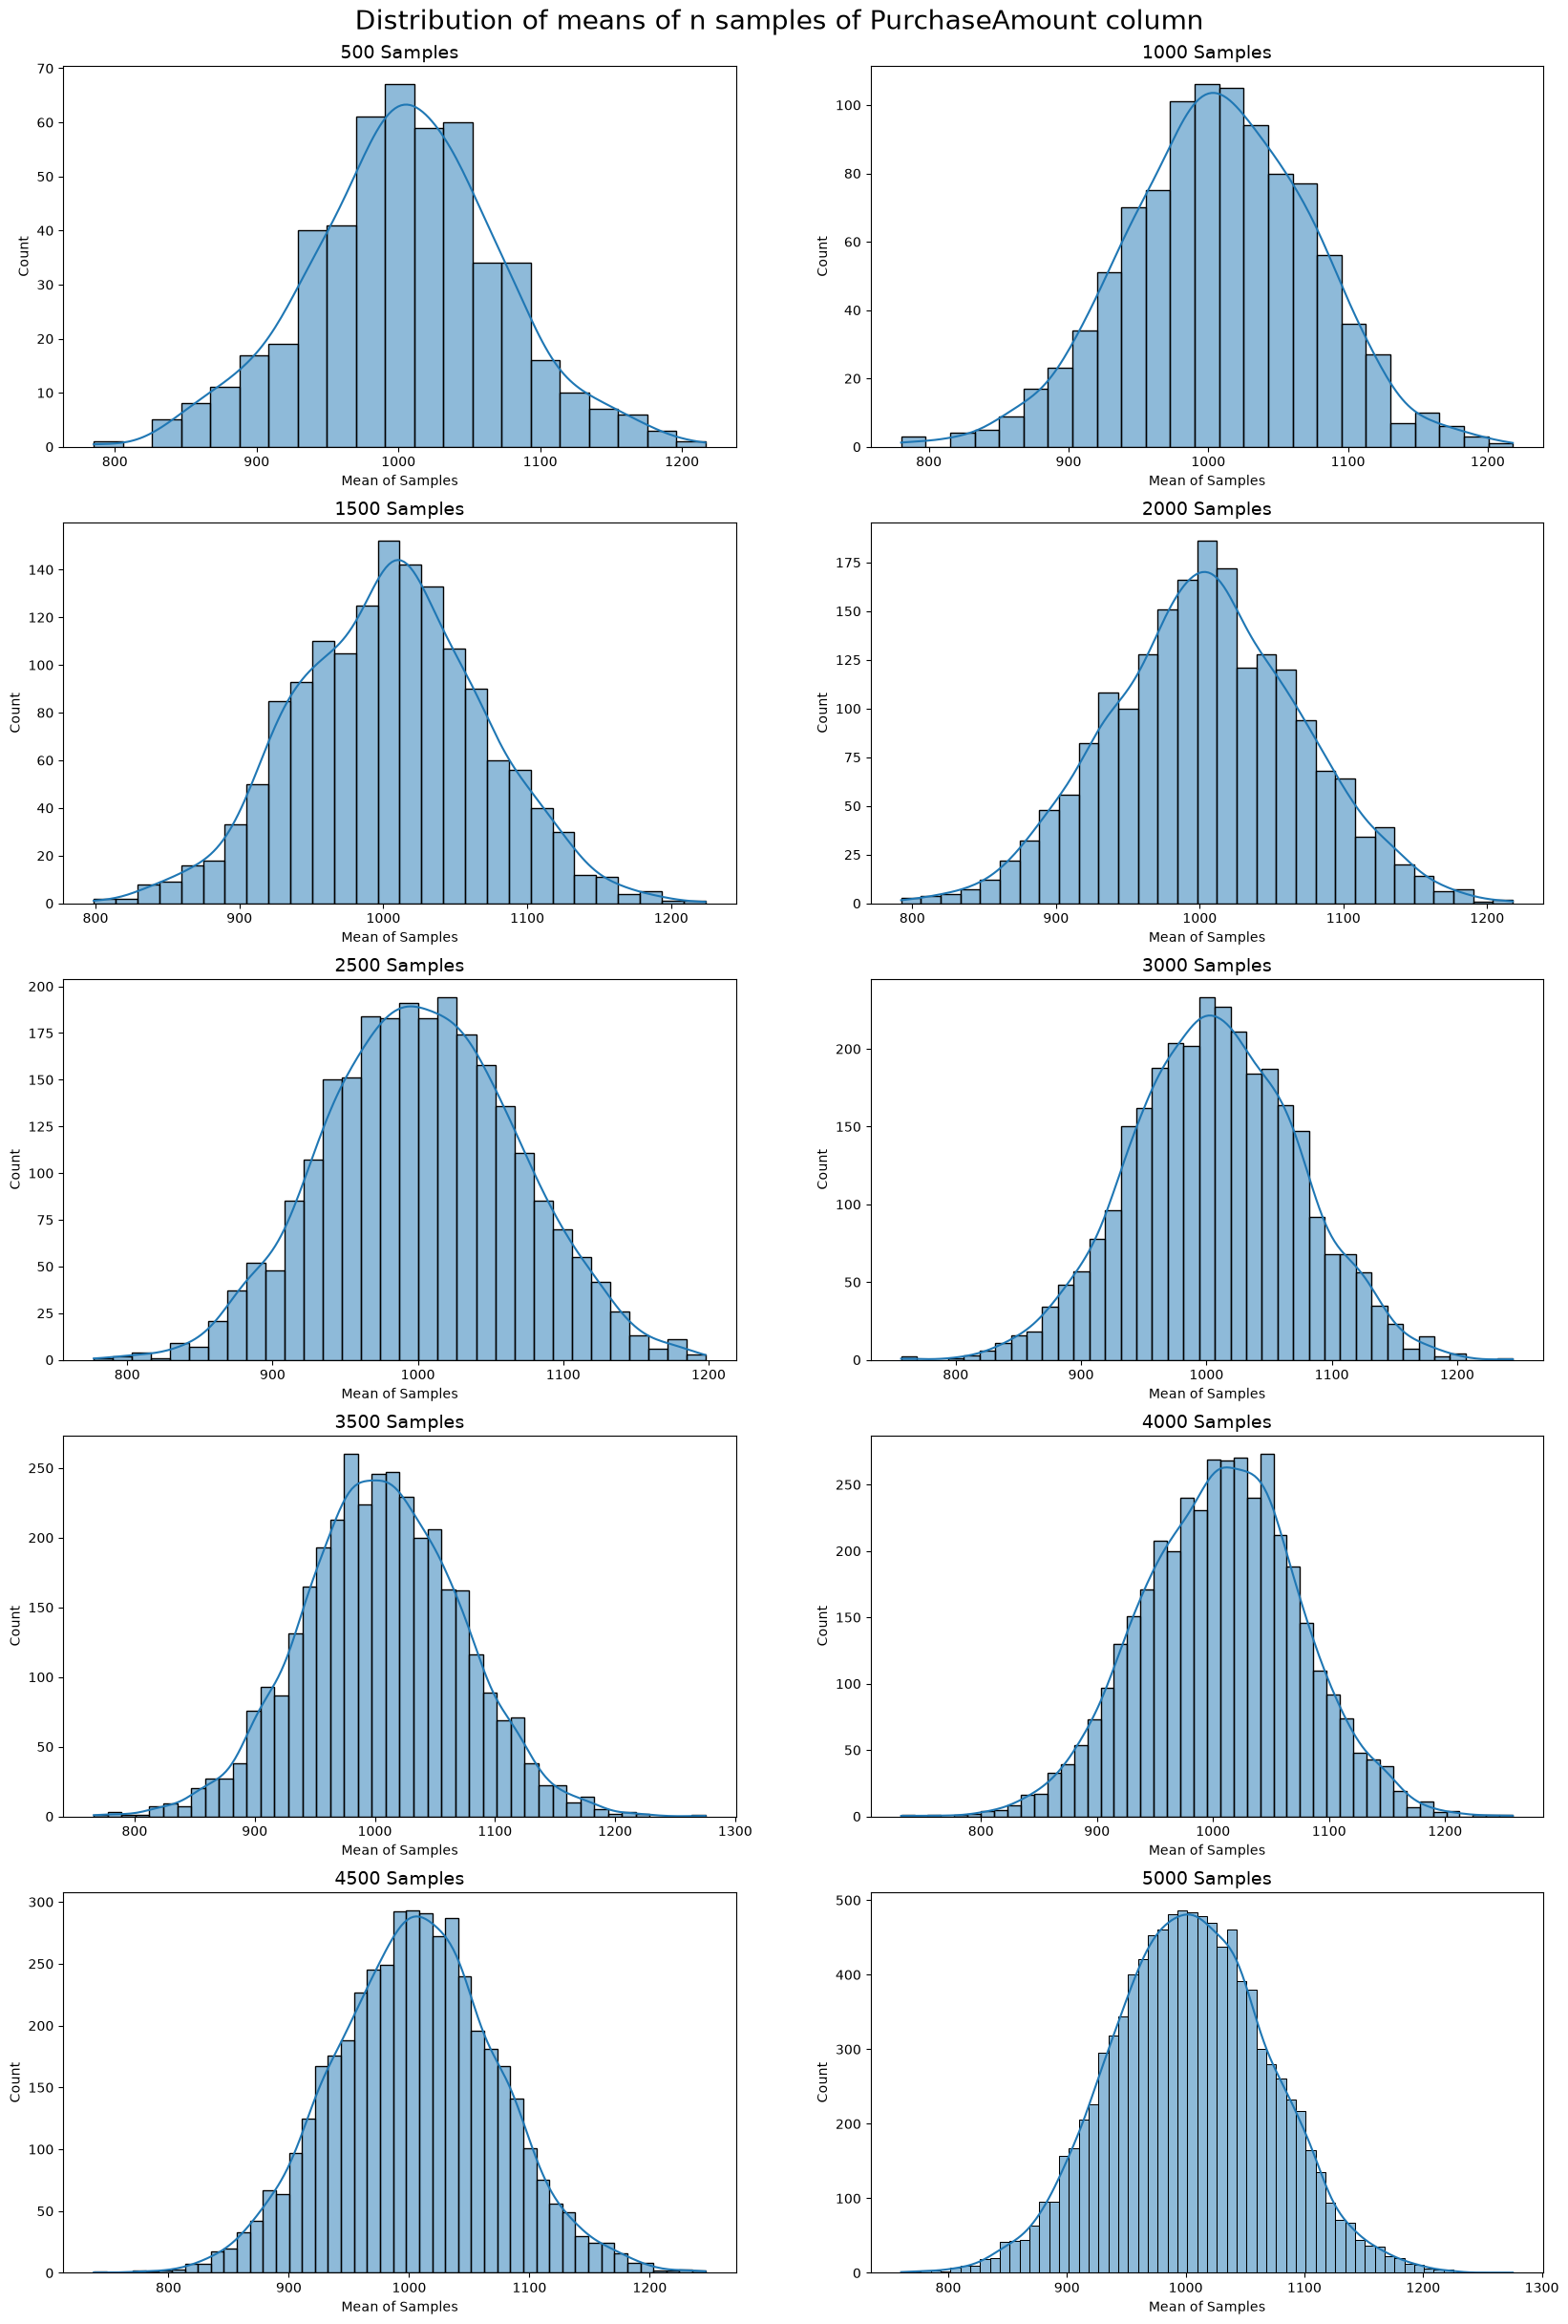

In [36]:
# Plotting a histogram
fig, ax=plt.subplots(5,2,figsize=(20,30))
fig.suptitle("Distribution of means of n samples of PurchaseAmount column", fontsize=20, y=0.90)

sns.histplot(x=means_of_samples_500, kde=True, ax=ax[0][0])
ax[0][0].set_title("500 Samples", fontsize=14)
ax[0][0].set_xlabel("Mean of Samples")
ax[0][0].set_ylabel("Count")

sns.histplot(x=means_of_samples_1000, kde=True, ax=ax[0][1])
ax[0][1].set_title("1000 Samples", fontsize=14)
ax[0][1].set_xlabel("Mean of Samples")
ax[0][1].set_ylabel("Count")

sns.histplot(x=means_of_samples_1500, kde=True, ax=ax[1][0])
ax[1][0].set_title("1500 Samples", fontsize=14)
ax[1][0].set_xlabel("Mean of Samples")
ax[1][0].set_ylabel("Count")

sns.histplot(x=means_of_samples_2000, kde=True, ax=ax[1][1])
ax[1][1].set_title("2000 Samples", fontsize=14)
ax[1][1].set_xlabel("Mean of Samples")
ax[1][1].set_ylabel("Count")

sns.histplot(x=means_of_samples_2500, kde=True, ax=ax[2][0])
ax[2][0].set_title("2500 Samples", fontsize=14)
ax[2][0].set_xlabel("Mean of Samples")
ax[2][0].set_ylabel("Count")

sns.histplot(x=means_of_samples_3000, kde=True, ax=ax[2][1])
ax[2][1].set_title("3000 Samples", fontsize=14)
ax[2][1].set_xlabel("Mean of Samples")
ax[2][1].set_ylabel("Count")

sns.histplot(x=means_of_samples_3500, kde=True, ax=ax[3][0])
ax[3][0].set_title("3500 Samples", fontsize=14)
ax[3][0].set_xlabel("Mean of Samples")
ax[3][0].set_ylabel("Count")

sns.histplot(x=means_of_samples_4000, kde=True, ax=ax[3][1])
ax[3][1].set_title("4000 Samples", fontsize=14)
ax[3][1].set_xlabel("Mean of Samples")
ax[3][1].set_ylabel("Count")

sns.histplot(x=means_of_samples_4500, kde=True, ax=ax[4][0])
ax[4][0].set_title("4500 Samples", fontsize=14)
ax[4][0].set_xlabel("Mean of Samples")
ax[4][0].set_ylabel("Count")

sns.histplot(x=means_of_samples_5000, kde=True, ax=ax[4][1])
ax[4][1].set_title("5000 Samples", fontsize=14)
ax[4][1].set_xlabel("Mean of Samples")
ax[4][1].set_ylabel("Count")

plt.show()

***It is observed that when we take large enough samples from the dataset the mean of these samples is following a normal distribution.***

## 95% confidence interval for the average PurchaseAmount (Que10)

In [37]:
from statsmodels.stats.weightstats import DescrStatsW

desc=DescrStatsW(data_copy['PurchaseAmount'])
interval_estimate=desc.tconfint_mean(alpha=0.05)
print(f"Average purchase amount with 95% confidence interval: {interval_estimate[0]} - {interval_estimate[1]}")

Average purchase amount with 95% confidence interval: 990.6101007375789 - 1016.9389992624208
